# Ocean Alkalinity Enhancement (OAE) analysis

This notebook analyzes the Iceland3_MARBL_2024 OAE experiments in Hvalfjörður, focusing on how an imposed alkalinity (and associated carbon) perturbation evolves and how efficiently it removes atmospheric CO₂.

- **Model setup**: Load Iceland3 BGC diagnostic (`*_bgc_dia`), BGC tracer, and `cstar` files and regrid them to fixed depth levels.
- **Surface snapshots**: Map pCO₂ anomalies, pH, ALK, and DIC anomalies over the upper fjord at selected times around the release.
- **Time series & metrics**: Use `roms_tools` CDR metrics to quantify cumulative CO₂ uptake and CDR efficiency (∑DIC/∑ALK) through time.
- **Background sensitivity**: Compare carbonate system responses for different assumed background Alk/DIC states using PyCO2SYS.
- **Integrated diagnostics**: Produce depth-integrated and time-integrated maps (e.g. cumulative FG_CO₂, vertically integrated DIC anomalies) to summarize the OAE signal.

Run the notebook from top to bottom when regenerating OAE figures or recomputing CDR metrics for updated simulations.

In [2]:
import subprocess
import os
import pandas as pd
import netCDF4
import numpy as np
import glob
import time
import matplotlib.pyplot as plt
import copy
import xarray as xr
from datetime import datetime, timedelta 
import dask
from scipy.interpolate import griddata
#from ocean_c_lab_tools import *
#from celluloid import Camera 
#import PyCO2SYS as csys
import seawater as sw
from roms_regrid import *

/tmp/ipykernel_2272261/3005166470.py:17: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [3]:
#HAFRO_path='/home/x-uheede/R/HAFRO/Hafro_cruises.xls'
model_grid_path="/home/x-uheede/S/Iceland3_MARBL_2024_60m/P_INPUT/Iceland3_grid_MAT.nc"
# Grid parameters, only modify these if grid is made in MATLAB
vert_levels=60
theta_s_model=5
theta_b_model=2
hc_model=300
model_bgc_dia_path="/home/x-uheede/S/Iceland3_MARBL_2024_60m_CDR/Iceland3_MARBL_2024_bgc_dia.202402[1-2]???????.nc"
variables_bgc_dia=['pH_3D','FG_CO2','FG_ALT_CO2','pCO2SURF','pCO2SURF_ALT_CO2']
variables_bgc=['ALK','ALK_ALT_CO2','DIC','DIC_ALT_CO2']
model_bgc_path="/home/x-uheede/S/Iceland3_MARBL_2024_60m_CDR/Iceland3_MARBL_2024_bgc.202402[1-2]???????.nc"
model_cstar_path="/home/x-uheede/S/Iceland3_MARBL_2024_60m_CDR/Iceland3_MARBL_2024_cstar.202402[1-2]???????.nc"

target_depth_levels=[1,2,3,4,5,6,7, 8, 9, 10, 15, 20] # Specify depth levels of interest
thinner=4 # specify the temporal frequency of data being read (i.e. no need to read in hourly data)


In [4]:
from roms_tools import Grid, ROMSOutput

grid = Grid.from_file(
    model_grid_path
)

#Only run this cell if grid is made in MATLAB
grid.update_vertical_coordinate(N=vert_levels, theta_s=theta_s_model, theta_b=theta_b_model, hc=hc_model, verbose=False)


2026-03-05 15:35:16 - WARNING - Vertical coordinates (Cs_r, Cs_w) not found in grid file.
2026-03-05 15:35:16 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 5.0, theta_b = 2.0, hc = 300.0 ===
2026-03-05 15:35:16 - INFO - Total time: 0.004 seconds
2026-03-05 15:35:16 - INFO - ================================================================================================


In [5]:
import xarray as xr
import numpy as np



# Load ROMS output using your pattern
roms_bgc_dia = ROMSOutput(
    grid=grid,
    path=[
        model_bgc_dia_path,
    ],
    use_dask=True,
)

roms_bgc = ROMSOutput(
    grid=grid,
    path=[
        model_bgc_path,
    ],
    use_dask=True,
)

roms_cstar = ROMSOutput(
    grid=grid,
    path=[
        model_cstar_path,
    ],
    use_dask=True,
)

ds_bgc_dia = roms_bgc_dia.regrid(depth_levels=target_depth_levels, var_names=variables_bgc_dia)

ds_bgc = roms_bgc.regrid(depth_levels=target_depth_levels, var_names=variables_bgc)



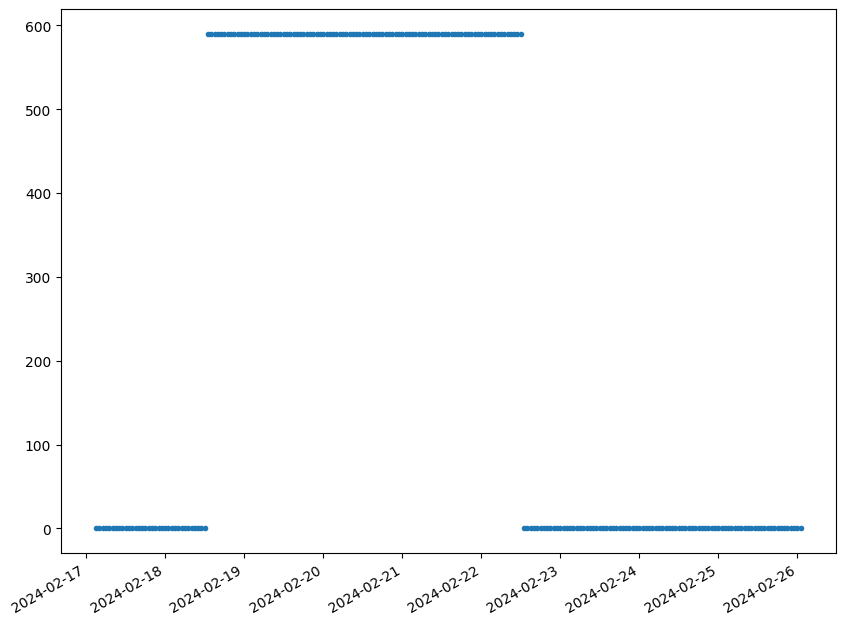

In [6]:
var_2_plot = 'ALK_source'

fig,axs = plt.subplots(1,1,figsize=(10,8))
plt.plot(roms_cstar.ds['time'], roms_cstar.ds[var_2_plot].values.sum(axis=(1,2,3)),'.') #, ls='.')
fig.autofmt_xdate()

2026-03-05 15:41:41 - INFO - Max absolute difference between flux-based and DIC-based uptake efficiency: 1.499e-04


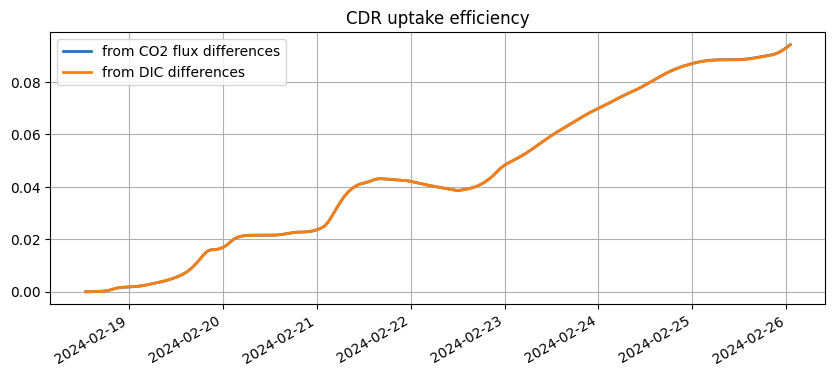

In [7]:
roms_cstar.cdr_metrics()

In [8]:
roms_cstar.ds_cdr

<xarray.Dataset> Size: 52GB
Dimensions:                         (time: 215, eta_rho: 386, xi_rho: 642,
                                     s_rho: 60)
Coordinates:
  * time                            (time) datetime64[ns] 2kB 2024-02-17T03:0...
    lon_rho                         (eta_rho, xi_rho) float64 2MB ...
    lat_rho                         (eta_rho, xi_rho) float64 2MB ...
Dimensions without coordinates: eta_rho, xi_rho, s_rho
Data variables:
    FG_CO2                          (time, eta_rho, xi_rho) float64 426MB dask.array<chunksize=(1, 386, 642), meta=np.ndarray>
    FG_ALT_CO2                      (time, eta_rho, xi_rho) float64 426MB dask.array<chunksize=(1, 386, 642), meta=np.ndarray>
    hDIC                            (time, s_rho, eta_rho, xi_rho) float64 26GB dask.array<chunksize=(1, 60, 386, 642), meta=np.ndarray>
    hDIC_ALT_CO2                    (time, s_rho, eta_rho, xi_rho) float64 26GB dask.array<chunksize=(1, 60, 386, 642), meta=np.ndarray>
    area                            (eta_rho, xi_rho) float64 2MB 2.5e+03 ......
    window_length                   (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    cdr_efficiency                  (time) float64 2kB nan nan ... 0.09429
    cdr_efficiency_from_delta_diff  (time) float64 2kB nan nan ... 0.09414

In [9]:
from pyproj import Geod
import matplotlib.pyplot as plt

def add_scalebar(ax, length_km, location=(0.1, 0.05), linewidth=3):
    """
    Add a scale bar to a Cartopy map.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        Map axes
    length_km : float
        Length of scale bar in kilometers
    location : tuple
        (x_frac, y_frac) position in axes coordinates
    linewidth : int
        Line width
    """

    geod = Geod(ellps="WGS84")

    # Get current map extent in PlateCarree
    lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())

    # Starting point
    lon_start = lon_min + location[0] * (lon_max - lon_min)
    lat_start = lat_min + location[1] * (lat_max - lat_min)

    # Compute endpoint using geodesic
    lon_end, lat_end, _ = geod.fwd(
        lon_start, lat_start,
        az=90,              # eastward
        dist=length_km * 1000
    )

    # Draw scale bar
    ax.plot(
        [lon_start, lon_end],
        [lat_start, lat_start],
        transform=ccrs.PlateCarree(),
        color="black",
        linewidth=linewidth
    )

    # Label
    ax.text(
        (lon_start + lon_end) / 2,
        lat_start + 0.002,
        f"{length_km} km",
        transform=ccrs.PlateCarree(),
        ha="center",
        va="bottom",
        fontsize=9
    )


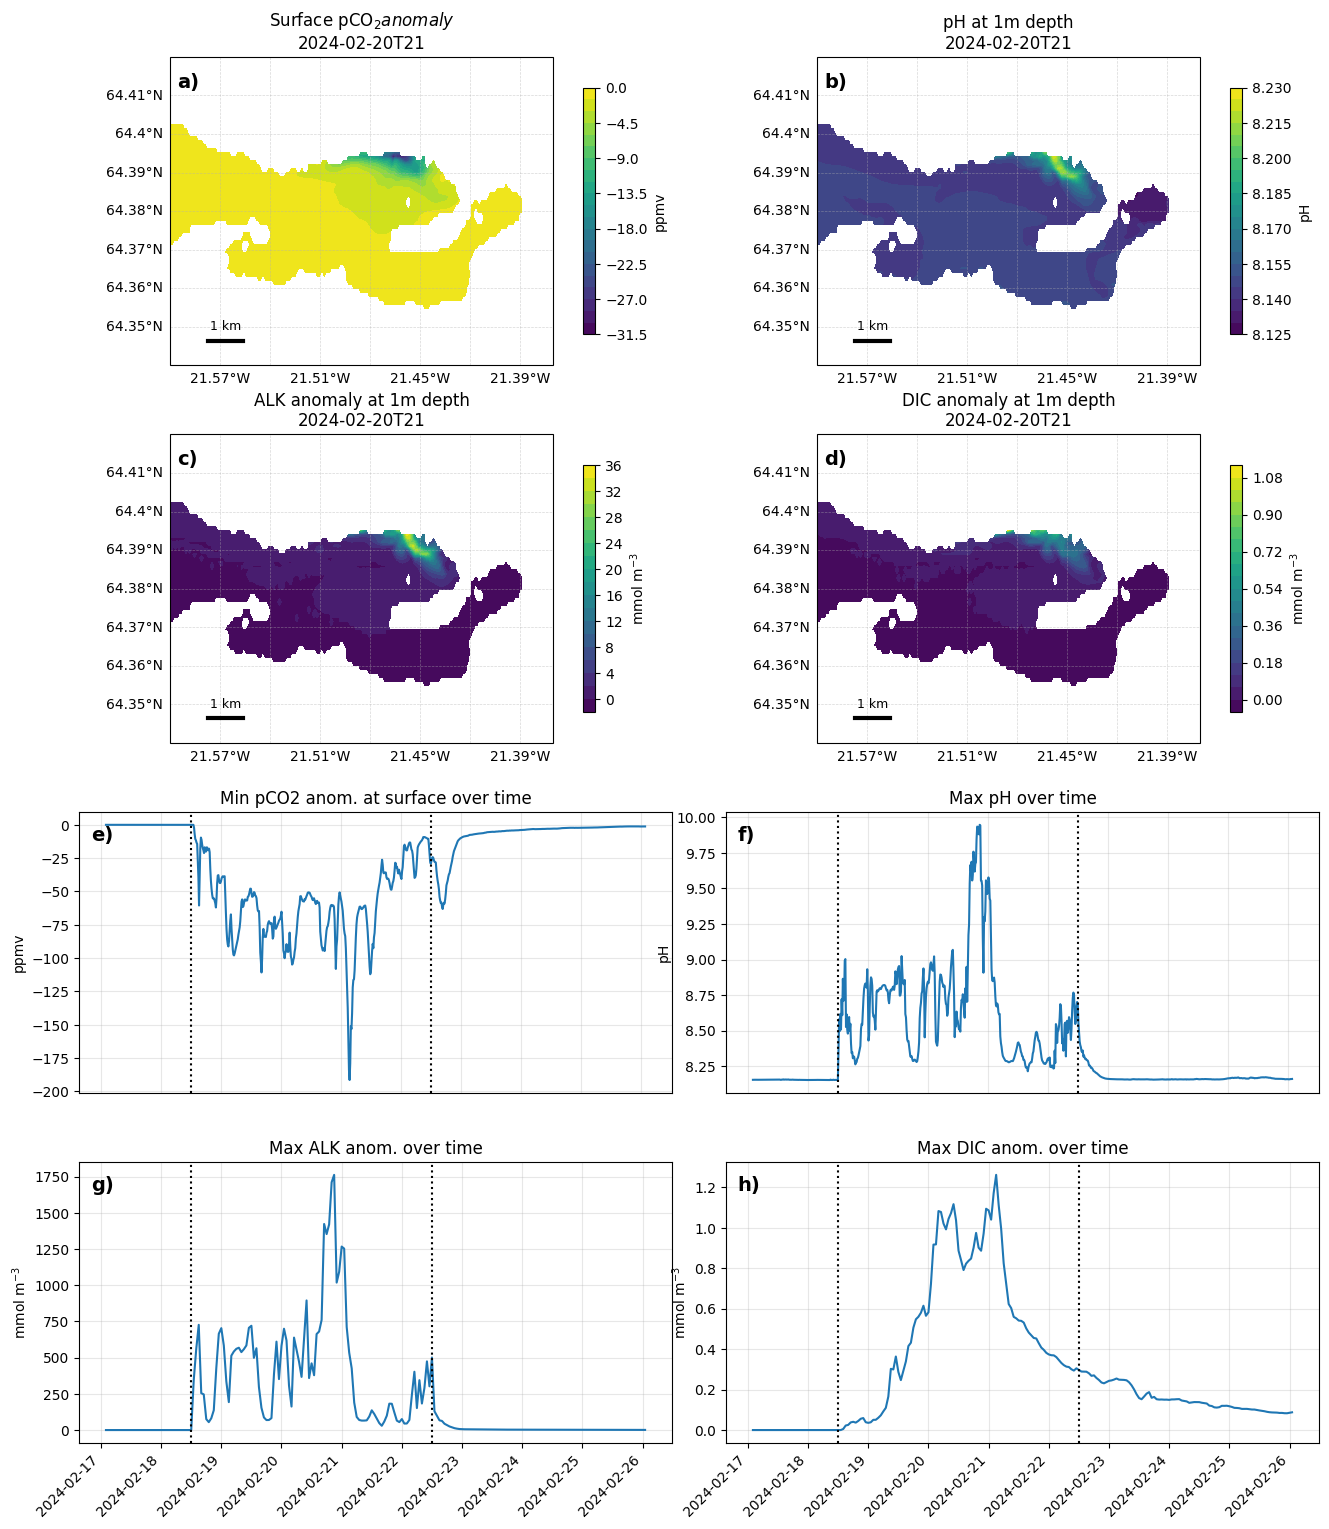

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Snapshot times
time_dia = np.datetime_as_string(
    ds_bgc_dia.time.sel(time="2024-02-20T21:00:00").values,
    unit="h"
)

time_tracer = np.datetime_as_string(
    ds_bgc.time.sel(time="2024-02-20T21:00:00").values,
    unit="h"
)

release_start = np.datetime64("2024-02-18T12:00:00")
release_end   = np.datetime64("2024-02-22T12:00:00")


# -------------------------------
# Hvalfjörður extent
# -------------------------------
lon_min, lon_max = -21.6, -21.37
lat_min, lat_max = 64.34, 64.42

# Convert if grid is 0–360
if ds_bgc_dia.lon.max() > 180:
    lon_min = lon_min % 360
    lon_max = lon_max % 360

proj = ccrs.Mercator()
t_index_tracer = 80
t_index_dia = 80*4

# ===============================
# 1. SNAPSHOTS (surface only)
# ===============================

# FG_CO2
FG_snapshot = (
    (ds_bgc_dia["pCO2SURF"]-ds_bgc_dia["pCO2SURF_ALT_CO2"])
    .sel(lon=slice(lon_min, lon_max),
         lat=slice(lat_min, lat_max))
    .sel(time=slice("2024-02-18T12:00:00","2024-02-22T12:00:00")).mean('time')
    .load()
)

# Surface pH
pH_surface = (
    ds_bgc_dia["pH_3D"]
    .sel(depth=1, method="nearest")
    .sel(lon=slice(lon_min, lon_max),
         lat=slice(lat_min, lat_max))
    .isel(time=t_index_dia)
    .load()
)

# ===============================
# Surface ALK anomaly
# ===============================

ALK_anom_surface = (
    (ds_bgc["ALK"] - ds_bgc["ALK_ALT_CO2"])
    .sel(depth=1, method="nearest")
    .sel(lon=slice(lon_min, lon_max),
         lat=slice(lat_min, lat_max))
    .isel(time=t_index_tracer)
    .load()
)

# ===============================
# Surface DIC anomaly
# ===============================

DIC_anom_surface = (
    (ds_bgc["DIC"] - ds_bgc["DIC_ALT_CO2"])
    .sel(depth=1, method="nearest")
    .sel(lon=slice(lon_min, lon_max),
         lat=slice(lat_min, lat_max))
    .isel(time=t_index_tracer)
    .load()
)


# ===============================
# 2. DOMAIN MAXIMA (1D only)
# ===============================

max_FG = (ds_bgc_dia["pCO2SURF"]-ds_bgc_dia["pCO2SURF_ALT_CO2"]).min(dim=("lat", "lon")).compute()

max_pH = (
    ds_bgc_dia["pH_3D"]
    .max(dim=("lat", "lon", "depth"))
    .compute()
)

max_ALK = (
    (ds_bgc["ALK"]-ds_bgc["ALK_ALT_CO2"])
    .max(dim=("lat", "lon", "depth"))
    .compute()
)

max_DIC = (
    (ds_bgc["DIC"]-ds_bgc["DIC_ALT_CO2"])
    .max(dim=("lat", "lon", "depth"))
    .compute()
)

time = ds_bgc_dia.time.values


# ===============================
# 3. Layout (2x2 maps)
# ===============================

fig = plt.figure(figsize=(16, 18))  # taller figure

# GridSpec: 6 rows total
# - Rows 0-1: maps (2 rows)
# - Rows 2-5: time series (2 rows, each taking 2 subrows)
gs = fig.add_gridspec(
    nrows=6,
    ncols=4,
    height_ratios=[3.5, 3.5, 1.2, 1.2, 1.2, 1.2],  # maps taller, time series shorter
    hspace=0.4  # vertical spacing
)

# ------------------------
# 2x2 Maps
# ------------------------
ax_c1 = fig.add_subplot(gs[0, 0:2], projection=proj)
ax_c2 = fig.add_subplot(gs[0, 2:4], projection=proj)
ax_c3 = fig.add_subplot(gs[1, 0:2], projection=proj)
ax_c4 = fig.add_subplot(gs[1, 2:4], projection=proj)

# ------------------------
# 2x2 Time series
# - Row 2-3: first row of TS
# - Row 4-5: second row of TS
# ------------------------
ax_ts1 = fig.add_subplot(gs[2:4, 0:2])
ax_ts2 = fig.add_subplot(gs[2:4, 2:4])
ax_ts3 = fig.add_subplot(gs[4:6, 0:2])
ax_ts4 = fig.add_subplot(gs[4:6, 2:4])

# Panel labels
panel_labels = ["a)", "b)", "c)", "d)", "e)", "f)", "g)", "h)"]

# ===============================
# 4. Map plotting helper (with lat/lon grid)
# ===============================
def plot_map(ax, data, title, panel_label):
    ax.set_extent(
        [lon_min, lon_max, lat_min, lat_max],
        crs=ccrs.PlateCarree()
    )

    cf = ax.contourf(
        data.lon,
        data.lat,
        data,
        levels=20,
        transform=ccrs.PlateCarree()
    )

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        linestyle="--",
        alpha=0.5
    )

    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(title)
    ax.text(0.02, 0.95, panel_label, transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top")
    add_scalebar(
    ax,
    length_km=1,        # good for upper Hvalfjörður
    location=(0.1, 0.08)
    )

    return cf


# Map plots
cf1 = plot_map(ax_c1, FG_snapshot, f"Surface pCO$_2 anomaly$\n{time_dia}", panel_labels[0])
cf2 = plot_map(ax_c2, pH_surface, f"pH at 1m depth\n{time_dia}", panel_labels[1])
cf3 = plot_map(ax_c3, ALK_anom_surface, f"ALK anomaly at 1m depth\n{time_tracer}", panel_labels[2])
cf4 = plot_map(ax_c4, DIC_anom_surface, f"DIC anomaly at 1m depth\n{time_tracer}", panel_labels[3])

cb1 = fig.colorbar(cf1, ax=ax_c1, shrink=0.8); cb1.set_label("ppmv")
cb2 = fig.colorbar(cf2, ax=ax_c2, shrink=0.8); cb2.set_label("pH")
cb3 = fig.colorbar(cf3, ax=ax_c3, shrink=0.8); cb3.set_label("mmol m$^{-3}$")
cb4 = fig.colorbar(cf4, ax=ax_c4, shrink=0.8); cb4.set_label("mmol m$^{-3}$")

# ===============================
# 5. Time series (2x2) with vertical lines and panel labels
# ===============================
ts_axes = [ax_ts1, ax_ts2, ax_ts3, ax_ts4]
ts_data = [
    (time, max_FG, "Min pCO2 anom. at surface", "ppmv"),
    (time, max_pH, "Max pH", "pH"),
    (ds_bgc.time.values, max_ALK, "Max ALK anom.", "mmol m$^{-3}$"),
    (ds_bgc.time.values, max_DIC, "Max DIC anom.", "mmol m$^{-3}$")
]

for i, ax in enumerate(ts_axes):
    t, y, ylabel, units = ts_data[i]
    ax.plot(t, y)
    ax.set_ylabel(units)
    ax.set_title(f"{ylabel} over time")
    ax.axvline(release_start, linestyle=":", linewidth=1.5, color='black')
    ax.axvline(release_end, linestyle=":", linewidth=1.5, color='black')
    ax.grid(True, alpha=0.3)
    ax.text(0.02, 0.95, panel_labels[i+4], transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top")
    
    # Tilt x-axis labels for all
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
        tick.set_horizontalalignment('right')
    
    # Remove x-axis labels for the upper row (first two plots)
    if i in [0, 1]:
        ax.set_xticklabels([])
        ax.tick_params(axis='x', which='both', length=0)  # optional: remove tick marks


#plt.tight_layout()
plt.show()



In [11]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import PyCO2SYS as pyco2


max_ALK = (
    ds_bgc["ALK"].sel(depth=slice(0,4))
    .max(dim=("lat", "lon", "depth"))
    .compute()
)
# -------------------------------
# 1. Extract max ALK timeseries
# -------------------------------

time = ds_bgc.time.values

# -------------------------------
# 2. Set background constants
# -------------------------------
BACKGROUND1 = dict(
    ALK = max_ALK+80,     # mmol/m3
    DIC = 2080.0,     # mmol/m3
    PO4 = 0.3,        ## mmol/m3
    Si = 2,         # mmol/m3
    T = 10.0,
    P = 0,
    S = 34.5,
)

BACKGROUND2 = dict(
    ALK = max_ALK,     # mmol/m3
    DIC = 2150.0,     # mmol/m3
    PO4 = 0.8,        ## mmol/m3
    Si = 6.8,         # mmol/m3
    T = 10.0,
    P = 0,
    S = 34)



In [12]:
import numpy as np
import PyCO2SYS as pyco2

def get_pCO2_with_volumetric_inputs(DATA):
    # 1. Extract values and ensure they are numpy arrays for consistency
    alk_vol = np.atleast_1d(DATA["ALK"])
    dic_vol = np.atleast_1d(DATA["DIC"])
    po4_vol = np.atleast_1d(DATA["PO4"])
    si_vol  = np.atleast_1d(DATA["Si"])
    
    # 2. Clean inputs: Replace negative flags (like -999) with NaN
    alk_vol[alk_vol < 0] = np.nan
    dic_vol[dic_vol < 0] = np.nan

    # 3. Calculate Density (rho)
    # We run a basic call to get the density factor (g/cm3, which is kg/L)
    # We'll use the provided T, S, and P
    temp_results = pyco2.sys(
        par1=alk_vol, 
        par2=dic_vol, 
        par1_type=1, 
        par2_type=2,
        salinity=DATA["S"], 
        temperature=DATA["T"], 
        pressure=DATA["P"]
    )
    rho = temp_results.get('rho', temp_results.get('density'))
    
    if rho is None:
        # Final fallback: manual calculation if the library isn't returning it
        # Based on your S=34.5 and T=10, rho is approximately 1.026 kg/L
        print("Warning: Density not found in results, using approximate seawater density.")
        rho = 1.026
        
    # 4. Convert mmol/m3 to umol/kg
    # Since 1 mmol/m3 = 1 umol/L, we divide by kg/L to get umol/kg
    alk_grav = alk_vol / rho
    dic_grav = dic_vol / rho
    po4_grav = po4_vol / rho
    si_grav  = si_vol / rho

    # 5. Final Marine Carbonate System Calculation
    return pyco2.sys(
        par1=alk_grav,
        par2=dic_grav,
        par1_type=1,
        par2_type=2,
        salinity=DATA["S"],
        temperature=DATA["T"],
        pressure=DATA["P"],
        total_phosphate=po4_grav,
        total_silicate=si_grav
    )

# Scenario 1
bg1 = get_pCO2_with_volumetric_inputs(BACKGROUND1)
pH_bg1 = bg1['pH_total']

# Scenario 1
bg1 = get_pCO2_with_volumetric_inputs(BACKGROUND2)
pH_bg2 = bg1['pH_total']

print(f"Calculated {len(pH_bg1)} pH values.")
print(f"Average pH: {np.nanmean(pH_bg1):.4f}")

Calculated 216 pH values.
Average pH: 8.4717


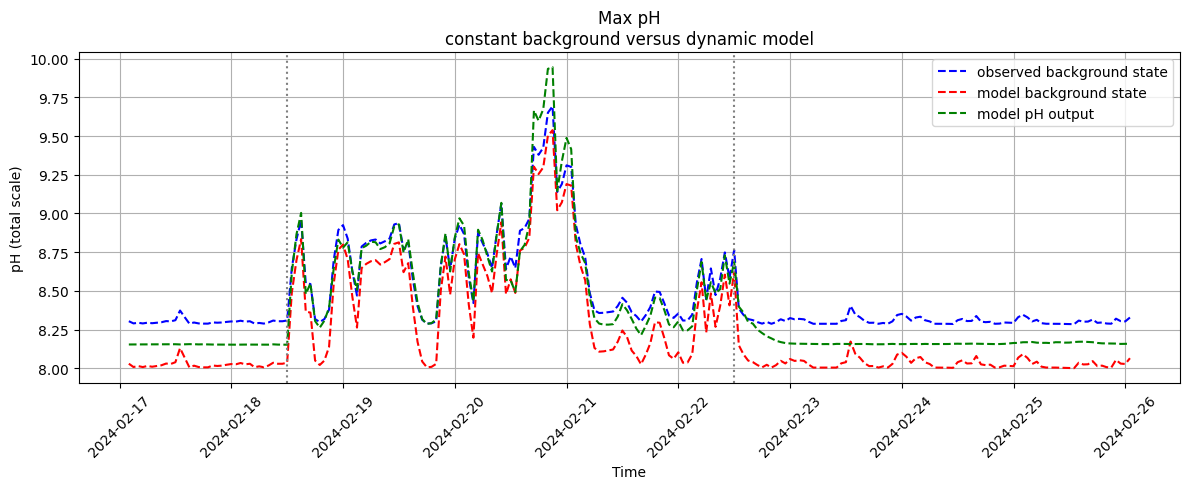

In [13]:
plt.figure(figsize=(12,5))

max_pH = (
    ds_bgc_dia["pH_3D"]
    .max(dim=("lat", "lon", "depth"))
    .thin(time=4)
    .compute()
)
# Constant background pH scenarios
plt.plot(max_pH.time, pH_bg1, linestyle='--', color='blue',label='observed background state')
plt.plot(max_pH.time, pH_bg2, linestyle='--', color='red',label='model background state')
plt.plot(max_pH.time, max_pH, linestyle='--', color='green',label='model pH output')

plt.xlabel("Time")
plt.ylabel("pH (total scale)")
plt.title("Max pH\nconstant background versus dynamic model")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Optional: vertical lines for release start/end
plt.axvline(release_start, linestyle=":", color="grey")
plt.axvline(release_end, linestyle=":", color="grey")

plt.tight_layout()
plt.show()


In [20]:
DIC_vert_int = (DIC_anom * dz_da).sum(dim="depth")
DIC_cum = (DIC_vert_int.isel(time=-1)).load()

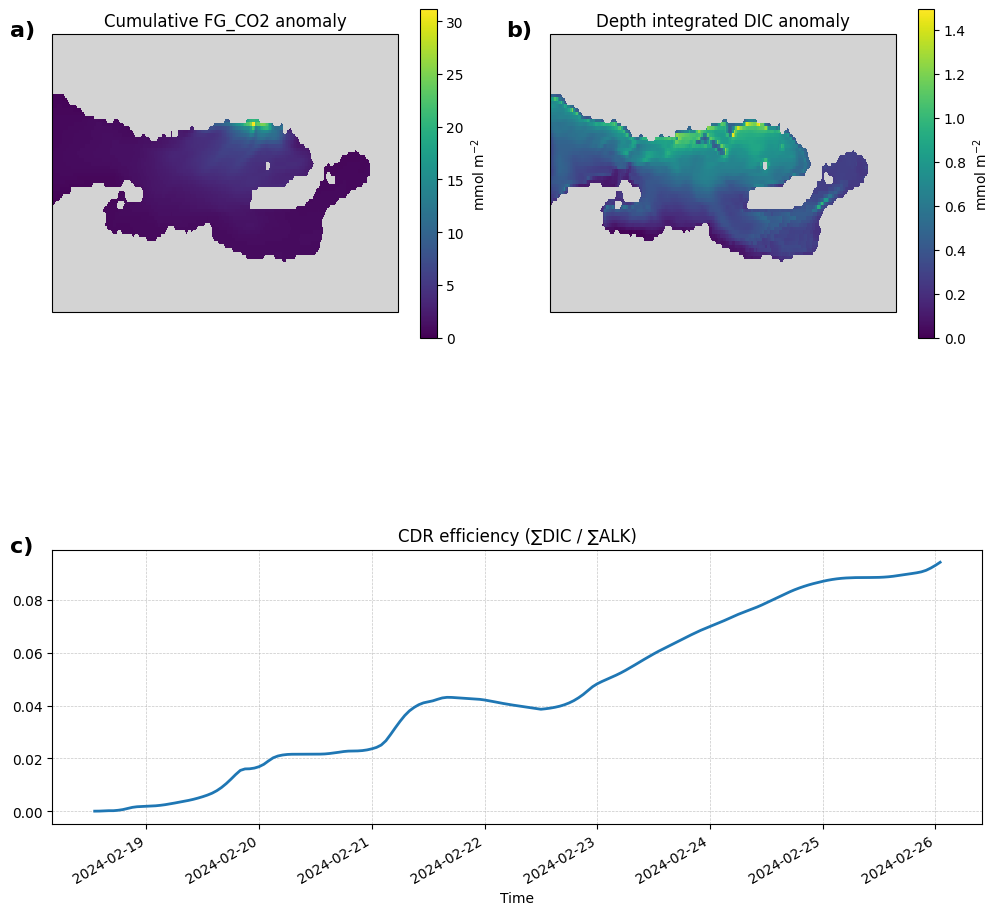

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec

lon_min, lon_max = -21.6, -21.37
lat_min, lat_max = 64.34, 64.42

# =========================
# --- TIME SERIES ---
# =========================
ds = roms_cstar.ds_cdr
time = ds["time"].values
eff = ds["cdr_efficiency"].values
mask_main = np.isfinite(eff)

# =========================
# --- FG CO2 ---
# =========================
FG_anom = ds_bgc_dia["FG_CO2"] - ds_bgc_dia["FG_ALT_CO2"]
FG_cum = (FG_anom.sum(dim="time")*3600).load()

# =========================
# --- COORDINATES ---
# =========================
lon = ds_bgc["lon"]
lat = ds_bgc["lat"]
land_mask = ds_bgc_dia["pCO2SURF"].isel(time=1).isnull().astype(int).load()

# =========================
# --- FIGURE LAYOUT ---
# =========================
fig = plt.figure(figsize=(12, 12))

gs = gridspec.GridSpec(
    nrows=2, ncols=2,
    height_ratios=[2, 1],
    hspace=0.25,
    wspace=0.15
)

proj = ccrs.Mercator()
pc = ccrs.PlateCarree()

def plot_map(ax, data, title, label, letter):

    ax.set_title(title)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=pc)

    ax.contourf(
        lon, lat, land_mask,
        levels=[0.5, 1.5],
        colors=["lightgrey"],
        transform=pc,
        zorder=2
    )

    im = ax.pcolormesh(
        lon, lat, data,
        transform=pc,
        shading="auto",
        zorder=1
    )

    cb = plt.colorbar(im, ax=ax, shrink=0.6)
    cb.set_label(label)

    ax.text(
        -0.05, 1.05, letter,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='right'
    )

# --- FG_CO2 MAP ---
ax_map1 = fig.add_subplot(gs[0, 0], projection=proj)
plot_map(ax_map1, FG_cum, "Cumulative FG_CO2 anomaly", "mmol m$^{-2}$", "a)")

# --- DIC MAP ---
ax_map2 = fig.add_subplot(gs[0, 1], projection=proj)
plot_map(ax_map2, DIC_cum, "Depth integrated DIC anomaly", "mmol m$^{-2}$", "b)")

# =========================
# --- TIME SERIES ---
# =========================
ax_ts = fig.add_subplot(gs[1, :])

ax_ts.plot(time[mask_main], eff[mask_main], linewidth=2)
ax_ts.set_title("CDR efficiency (∑DIC / ∑ALK)")
ax_ts.set_xlabel("Time")
ax_ts.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

ax_ts.text(
    -0.02, 1.05, "c)",
    transform=ax_ts.transAxes,
    fontsize=16,
    fontweight='bold',
    va='top',
    ha='right'
)

plt.setp(ax_ts.get_xticklabels(), rotation=30, ha="right")

plt.show()